## 教程目标

使用 cell2location 将 scRNA-seq 参考细胞类型映射到 10X Visium 空间点位，估计每个 spot 中各细胞类型的丰度，并进行可视化与下游组织结构分析。

## 总体流程（方法学视角）

1. **准备数据**：空间转录组（Visium） + 单细胞参考（scRNA-seq）
2. **构建参考 signatures**：用负二项回归（RegressionModel）估计每种细胞类型的基因表达特征
3. **空间映射**：用 Cell2location 模型反卷积每个 spot 的细胞组成
4. **质量控制与可视化**：检查拟合质量并展示空间分布
5. **下游分析**：区域聚类

## 1. 导入核心库

**目的**：引入单细胞分析、可视化和 cell2location 模型组件。  
**原理**：
- `scanpy`：AnnData 操作、邻接图、UMAP、聚类与绘图
- `cell2location`：参考模型 + 空间映射模型

In [1]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import cell2location

from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42  # 避免导出 PDF 时字体变形

/data/work/sdas-1.0.0/anno/anaconda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data/work/sdas-1.0.0/anno/anaconda/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/data/work/sdas-1.0.0/anno/anaconda/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/data/work/sdas-1.0.0/anno/anaconda/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/data/work/sdas-1.0.0/anno/anaconda/lib/python3.10/site-p

## 2. 设置输出目录

**目的**：统一保存中间结果和最终模型。  
**原理**：将“参考签名模型”和“空间映射模型”输出分开，便于复用与排错。

In [2]:
results_folder = './results/lymph_nodes_analysis/'
ref_run_name = f'{results_folder}/reference_signatures'
run_name = f'{results_folder}/cell2location_map'

## 3. 读取空间数据

**目的**：获得待反卷积的空间转录组数据。  
**关键点**：cell2location 需要**原始计数矩阵（未标准化、未 log）**。

In [3]:
# Visium 数据
adata_vis = sc.read_visium(
    path="/data/work/data/V1_Human_Lymph_Node",  # 数据所在文件夹路径
    count_file="filtered_feature_bc_matrix.h5"  # 指定h5文件名
)

adata_vis.obs['sample'] = list(adata_vis.uns['spatial'].keys())[0]

# 使用 ENSEMBL ID 作为 var_names
adata_vis.var['SYMBOL'] = adata_vis.var_names
adata_vis.var.set_index('gene_ids', drop=True, inplace=True)

# 去除线粒体基因（保留原始计数在 obsm）
adata_vis.var['MT_gene'] = [gene.startswith('MT-') for gene in adata_vis.var['SYMBOL']]
adata_vis.obsm['MT'] = adata_vis[:, adata_vis.var['MT_gene'].values].X.toarray()
adata_vis = adata_vis[:, ~adata_vis.var['MT_gene'].values]

/tmp/ipykernel_842/2503590498.py:2: FutureWarning: Use `squidpy.read.visium` instead.
  adata_vis = sc.read_visium(
/data/work/sdas-1.0.0/anno/anaconda/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/data/work/sdas-1.0.0/anno/anaconda/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


### 3.1 去除线粒体基因用于建模

**目的**：减少技术噪音对映射的干扰。  
**原理**：线粒体转录本常反映测序质量/应激状态而非真实细胞组成；保留在 `obsm['MT']` 便于后续质控。

In [4]:
adata_vis.var['MT_gene'] = [gene.startswith('MT-') for gene in adata_vis.var['SYMBOL']]
adata_vis.obsm['MT'] = adata_vis[:, adata_vis.var['MT_gene'].values].X.toarray()
adata_vis = adata_vis[:, ~adata_vis.var['MT_gene'].values]

/tmp/ipykernel_842/2231415175.py:1: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata_vis.var['MT_gene'] = [gene.startswith('MT-') for gene in adata_vis.var['SYMBOL']]


## 4. 读取 scRNA-seq 参考数据

**目的**：提供“细胞类型表达模板（signature）”的训练数据。  
**原理**：cell2location 先从单细胞数据学习每个 cell type 的表达均值结构，再投射到空间。

In [5]:
# 读取 scRNA-seq 参考数据
adata_ref = sc.read('/data/work/data/sc.h5ad')

adata_ref.var['SYMBOL'] = adata_ref.var.index
adata_ref.var.set_index('GeneID-2', drop=True, inplace=True)

if hasattr(adata_ref, 'raw') and adata_ref.raw is not None:
    del adata_ref.raw

### 4.1 参考基因筛选（温和过滤）

**目的**：保留信息基因，移除低信息噪音基因。  
**原理**：与 HVG 不同，这里倾向保留稀有细胞类型 marker，避免稀有群体信号丢失。

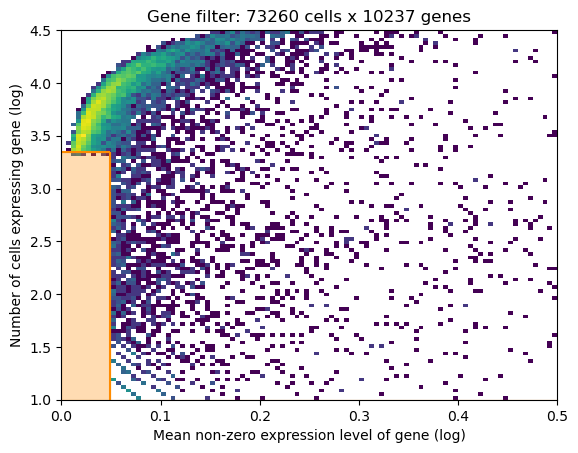

In [6]:
from cell2location.utils.filtering import filter_genes

selected = filter_genes(
    adata_ref,
    cell_count_cutoff=5,
    cell_percentage_cutoff2=0.03,
    nonz_mean_cutoff=1.12,
)
adata_ref = adata_ref[:, selected].copy()

## 5. 训练参考模型（RegressionModel）

**目的**：估计每个 cell type 在每个基因上的期望表达（signature）。  
**原理**：负二项回归同时建模计数离散性与批次/技术协变量，减少跨批次偏差。

In [7]:
cell2location.models.RegressionModel.setup_anndata(
    adata=adata_ref,
    batch_key='Sample',      # 生物/实验批次
    labels_key='Subset',     # 细胞类型标签
    categorical_covariate_keys=['Method']  # 技术协变量（例如 3'/5'）
)

from cell2location.models import RegressionModel
mod_ref = RegressionModel(adata_ref)
mod_ref.view_anndata_setup()

Anndata setup with scvi-tools version 1.1.2.

Setup via `RegressionModel.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'Sample',
│   'labels_key': 'Subset',
│   'categorical_covariate_keys': ['Method'],
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │  23   │
│         n_cells          │ 73260 │
│ n_extra_categorical_covs │   1   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │  34   │
│          n_vars          │ 10237 │
└──────────────────────────┴───────┘

                             Data Registry                             
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Registry Key      ┃            scvi-tools Location             ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X            │                  adata.X                   │
│         batch          │          adata.obs['_scvi_batch']          │
│ extra_categorical_covs │ adata.obsm['_scvi_extra_categorical_covs'] │
│         ind_x          │           adata.obs['_indices']            │
│         labels         │         adata.obs['_scvi_labels']          │
└────────────────────────┴────────────────────────────────────────────┘

                         batch State Registry                         
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃       Categories       ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['Sample'] │    4861STDY7135913     │          0          │
│                     │    4861STDY7135914     │          1          │
│                     │    4861STDY7208412     │          2          │
│                     │    4861STDY7208413     │          3          │
│                     │    4861STDY7462253     │          4          │
│                     │    4861STDY7462254     │          5          │
│                     │    4861STDY7462255     │          6          │
│                     │    4861STDY7462256     │          7          │
│                     │    4861STDY7528597     │          8          │
│                     │    4861STDY7528598     │          9          │
│                     │    4861STDY7528599     │         10          │
│                     │    4861STDY7528600     │         11          │
│                     │      BCP002_Total      │         12          │
│                     │      BCP003_Total      │         13          │
│                     │      BCP004_Total      │         14          │
│                     │      BCP005_Total      │         15          │
│                     │      BCP006_Total      │         16          │
│                     │      BCP008_Total      │         17          │
│                     │      BCP009_Total      │         18          │
│                     │ Human_colon_16S7255677 │         19          │
│                     │ Human_colon_16S7255678 │         20          │
│                     │ Human_colon_16S8000484 │         21          │
│                     │      Pan_T7935494      │         22          │
└─────────────────────┴────────────────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃    Categories    ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['Subset'] │    B_Cycling     │          0          │
│                     │     B_GC_DZ      │          1          │
│                     │     B_GC_LZ      │          2          │
│                     │    B_GC_prePB    │          3          │
│                     │      B_IFN       │          4          │
│                     │   B_activated    │          5          │
│                     │      B_mem       │          6          │
│                     │     B_naive      │          7          │
│                     │     B_plasma     │          8          │
│                     │     B_preGC      │          9          │
│                     │     DC_CCR7+     │         10          │
│                     │     DC_cDC1      │         11          │
│                     │     DC_cDC2      │         12          │
│                     │      DC_pDC      │         13          │
│                     │       Endo       │         14          │
│                     │       FDC        │         15          │
│                     │       ILC        │         16          │
│                     │  Macrophages_M1  │         17          │
│                     │  Macrophages_M2  │         18          │
│                     │       Mast       │         19          │
│                     │    Monocytes     │         20          │
│                     │        NK        │         21          │
│                     │       NKT        │         22          │
│                     │      T_CD4+      │         23          │
│                     │    T_CD4+_TfH    │         24          │
│                     │  T_CD4+_TfH_GC   │         25          │
│                     │   T_CD4+_naive   │         26          │
│                     │  T_CD8+_CD161+   │         27          │
│                     │ T_CD8+_cytotoxic │         28          │
│                     │   T_CD8+_naive   │         29          │
│                     │     T_TIM3+      │         30          │
│                     │      T_TfR       │         31          │
│                     │      T_Treg      │         32          │
│                     │       VSMC       │         33          │
└─────────────────────┴──────────────────┴─────────────────────┘

          extra_categorical_covs State Registry           
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['Method'] │    3GEX    │          0          │
│                     │    5GEX    │          1          │
│                     │            │                     │
└─────────────────────┴────────────┴─────────────────────┘

### 5.1 训练与收敛检查

**目的**：优化模型参数得到稳定的 signature。  
**判断原则**：ELBO 曲线应下降后趋于平稳；若末端仍明显下降，可增加 `max_epochs`。

In [8]:
help(mod_ref.train)

Help on method train in module cell2location.models.reference._reference_model:

train(max_epochs: Optional[int] = None, batch_size: int = 2500, train_size: float = 1, lr: float = 0.002, **kwargs) method of cell2location.models.reference._reference_model.RegressionModel instance
    Train the model with useful defaults
    
    Parameters
    ----------
    max_epochs
        Number of passes through the dataset. If `None`, defaults to
        `np.min([round((20000 / n_cells) * 400), 400])`
    train_size
        Size of training set in the range [0.0, 1.0].
    batch_size
        Minibatch size to use during training. If `None`, no minibatching occurs and all
        data is copied to device (e.g., GPU).
    lr
        Optimiser learning rate (default optimiser is :class:`~pyro.optim.ClippedAdam`).
        Specifying optimiser via plan_kwargs overrides this choice of lr.
    kwargs
        Other arguments to scvi.model.base.PyroSviTrainMixin().train() method



GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/data/work/sdas-1.0.0/anno/anaconda/lib/python3.10/site-packages/lightning/pytorch/trainer/configuration_validator.py:72: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
/data/work/sdas-1.0.0/anno/anaconda/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/data/work/sdas-1.0.0/anno/anaconda/lib/python3.10/site-packages/lightning/pytorch/loops/fit_loop.py:293: The number of training batches (8) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 150/150: 100%|██████████| 150/150 [06:09<00:00,  2.52s/it, v_num=1, elbo_train=3.01e+7]

`Trainer.fit` stopped: `max_epochs=150` reached.


Epoch 150/150: 100%|██████████| 150/150 [06:09<00:00,  2.46s/it, v_num=1, elbo_train=3.01e+7]


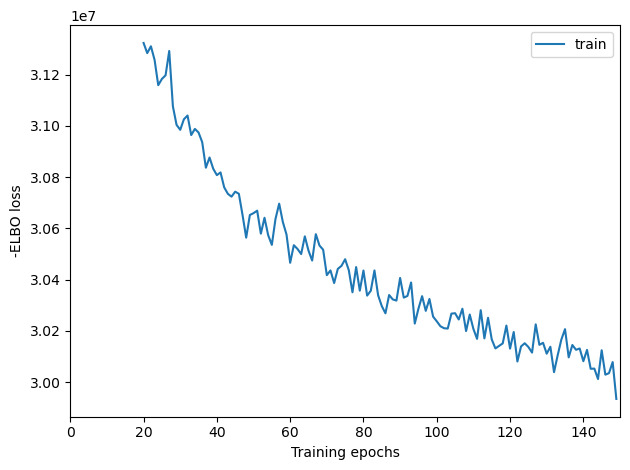

In [9]:
mod_ref.train(max_epochs=150, batch_size=1000,train_size = 0.1) 
mod_ref.plot_history(20)

### 5.2 导出参考后验并保存

**目的**：保存可复用的参考结果，避免重复训练。  
**原理**：通过后验采样估计参数均值/不确定性。

In [10]:
adata_ref = mod_ref.export_posterior(
    adata_ref,
    sample_kwargs={'batch_size': 1000}
)

mod_ref.save(f"{ref_run_name}", overwrite=True)
adata_ref_file = f"{ref_run_name}/sc.h5ad"
adata_ref.write(adata_ref_file)
adata_ref_file

Sampling global variables, sample: 100%|██████████| 999/999 [00:43<00:00, 22.99it/s]


'./results/lymph_nodes_analysis//reference_signatures/sc.h5ad'

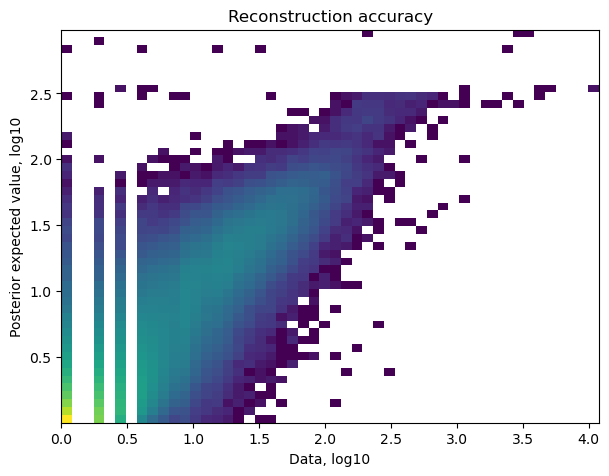

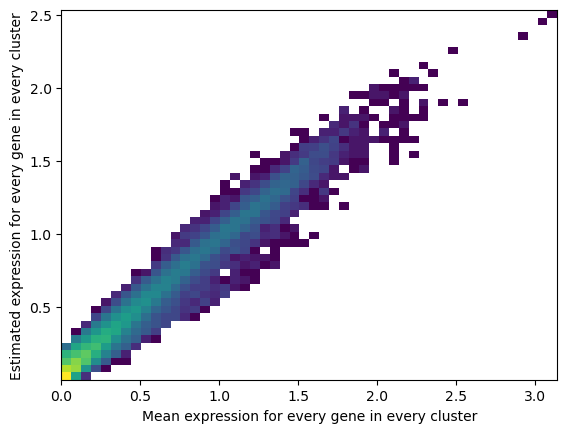

In [11]:
# 参考模型 QC：重建精度与 signature 合理性
mod_ref.plot_QC()

### 5.3 提取 cell type signatures 矩阵

**目的**：构建 `cell_state_df`（基因 × 细胞类型）供空间映射模型使用。  
**原理**：每个元素表示该 cell type 在该基因上的期望表达水平。

In [12]:
if 'means_per_cluster_mu_fg' in adata_ref.varm.keys():
    inf_aver = adata_ref.varm['means_per_cluster_mu_fg'][
        [f'means_per_cluster_mu_fg_{i}' for i in adata_ref.uns['mod']['factor_names']]
    ].copy()
else:
    inf_aver = adata_ref.var[
        [f'means_per_cluster_mu_fg_{i}' for i in adata_ref.uns['mod']['factor_names']]
    ].copy()

inf_aver.columns = adata_ref.uns['mod']['factor_names']
inf_aver.iloc[:5, :5]

,B_Cycling,B_GC_DZ,B_GC_LZ,B_GC_prePB,B_IFN
GeneID-2,,,,,
ENSG00000188976,0.406249,0.182340,0.343923,0.200820,0.215894
ENSG00000188290,0.003119,0.004837,0.004501,0.074809,0.110713
ENSG00000187608,0.461235,0.283981,0.342797,0.280480,2.366148
ENSG00000186891,0.014433,0.007331,0.057346,0.197563,0.032599
ENSG00000186827,0.009304,0.004407,0.014360,0.127400,0.031719


## 6. Cell2location 空间映射

**目的**：将每个 spot 表示为多个细胞类型丰度的组合。  
**核心思想**：贝叶斯分解 + 技术噪音建模（检测灵敏度、背景 RNA 等）。

In [13]:
# 仅保留空间与参考共同基因，保证矩阵对齐
intersect = np.intersect1d(adata_vis.var_names, inf_aver.index)
adata_vis = adata_vis[:, intersect].copy()
inf_aver = inf_aver.loc[intersect, :].copy()

# 注册空间数据
cell2location.models.Cell2location.setup_anndata(adata=adata_vis, batch_key='sample')

### 6.1 构建模型与超参数解释

- `N_cells_per_location`：每个 spot 的预期细胞数先验（组织依赖）
- `detection_alpha`：检测灵敏度正则强度（技术波动大时可适当降低）

**实践建议**：常比较 `detection_alpha=20` 与 `200` 的结果一致性。

In [14]:
mod_sp = cell2location.models.Cell2location(
    adata_vis,
    cell_state_df=inf_aver,
    N_cells_per_location=30,
    detection_alpha=20,
)
mod_sp.view_anndata_setup()

Anndata setup with scvi-tools version 1.1.2.

Setup via `Cell2location.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'sample',
│   'labels_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   1   │
│         n_cells          │ 4035  │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   1   │
│          n_vars          │ 10217 │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                       batch State Registry                        
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃     Categories      ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample'] │ V1_Human_Lymph_Node │          0          │
└─────────────────────┴─────────────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

### 6.2 训练空间模型

**目的**：得到每个 spot 的后验细胞丰度分布。  
**说明**：`train_size=1` 表示所有 spot 都参与训练并被估计。

In [15]:
help(mod_sp.train)

Help on method train in module cell2location.models._cell2location_model:

train(max_epochs: int = 30000, batch_size: int = None, train_size: float = 1, lr: float = 0.002, num_particles: int = 1, scale_elbo: float = 1.0, **kwargs) method of cell2location.models._cell2location_model.Cell2location instance
    Train the model with useful defaults
    
    Parameters
    ----------
    max_epochs
        Number of passes through the dataset. If `None`, defaults to
        `np.min([round((20000 / n_cells) * 400), 400])`
    train_size
        Size of training set in the range [0.0, 1.0]. Use all data points in training because
        we need to estimate cell abundance at all locations.
    batch_size
        Minibatch size to use during training. If `None`, no minibatching occurs and all
        data is copied to device (e.g., GPU).
    lr
        Optimiser learning rate (default optimiser is :class:`~pyro.optim.ClippedAdam`).
        Specifying optimiser via plan_kwargs overrides this ch

In [ ]:
mod_sp.train(
    max_epochs=300,
    batch_size=None,
    train_size=1
)

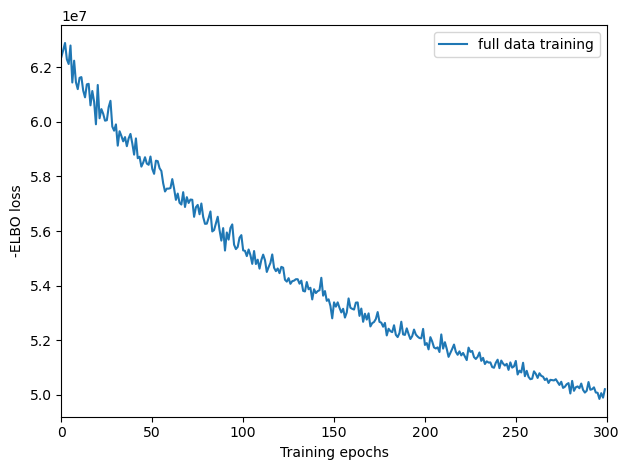

In [33]:
mod_sp.plot_history()
plt.legend(labels=['full data training'])

### 6.3 导出后验并保存

**目的**：提取每个 spot 的细胞丰度后验统计量（均值、分位数等）并写盘。

In [17]:
adata_vis = mod_sp.export_posterior(
    adata_vis,
    sample_kwargs={'num_samples': 1000, 'batch_size': mod_sp.adata.n_obs}
)

mod_sp.save(f"{run_name}", overwrite=True)
adata_sp_file = f"{run_name}/sp.h5ad"
adata_vis.write(adata_sp_file)
adata_sp_file

Sampling global variables, sample: 100%|██████████| 999/999 [01:50<00:00,  9.08it/s]


'./results/lymph_nodes_analysis//cell2location_map/sp.h5ad'

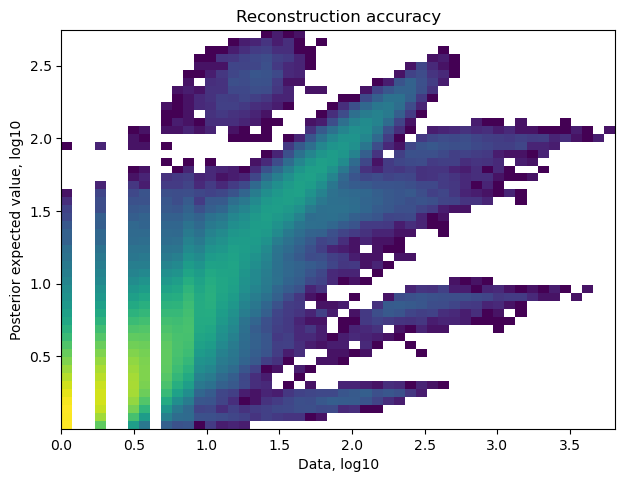

In [18]:
# 空间映射 QC：观察重建是否接近对角线
mod_sp.plot_QC()

## 7. 空间可视化

**目的**：展示细胞类型在组织切片上的空间分布。  
**原理**：常用后验 5% 分位数（q05）作为“保守存在量”，降低假阳性。

/tmp/ipykernel_842/3611388320.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


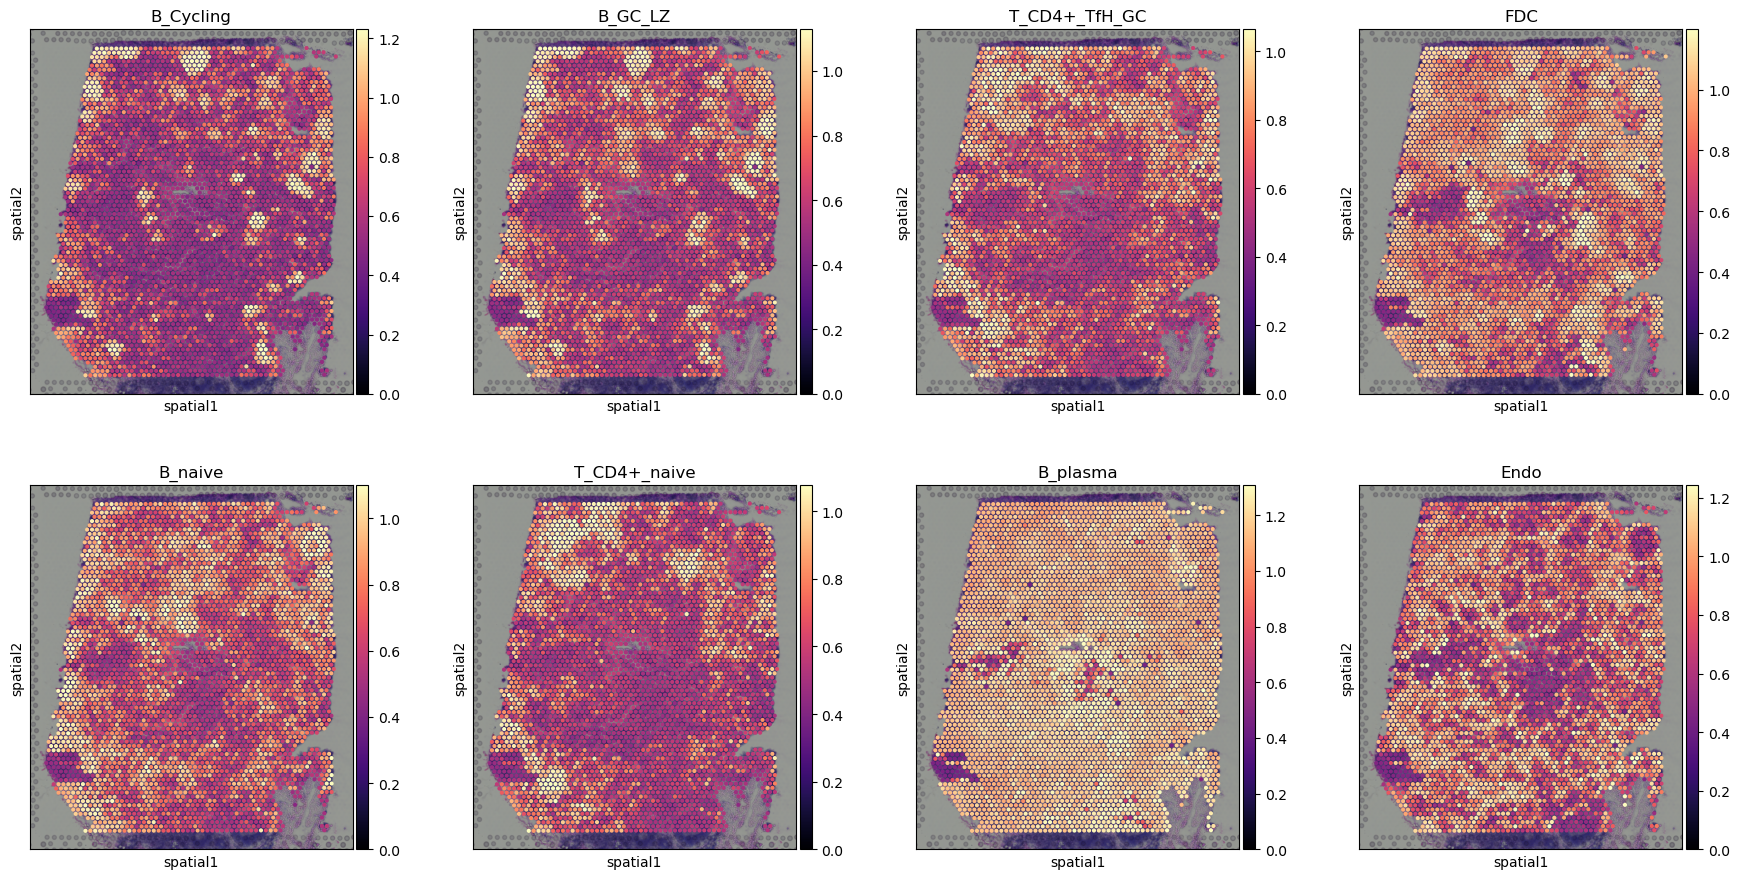

In [19]:
adata_vis.obs[adata_vis.uns['mod']['factor_names']] = adata_vis.obsm['q05_cell_abundance_w_sf']

from cell2location.utils import select_slide
slide = select_slide(adata_vis, 'V1_Human_Lymph_Node')

with mpl.rc_context({'axes.facecolor': 'black', 'figure.figsize': [4.5, 5]}):
    sc.pl.spatial(
        slide,
        cmap='magma',
        color=['B_Cycling', 'B_GC_LZ', 'T_CD4+_TfH_GC', 'FDC',
               'B_naive', 'T_CD4+_naive', 'B_plasma', 'Endo'],
        ncols=4,
        size=1.3,
        img_key='hires',
        vmin=0,
        vmax='p99.2',
    )

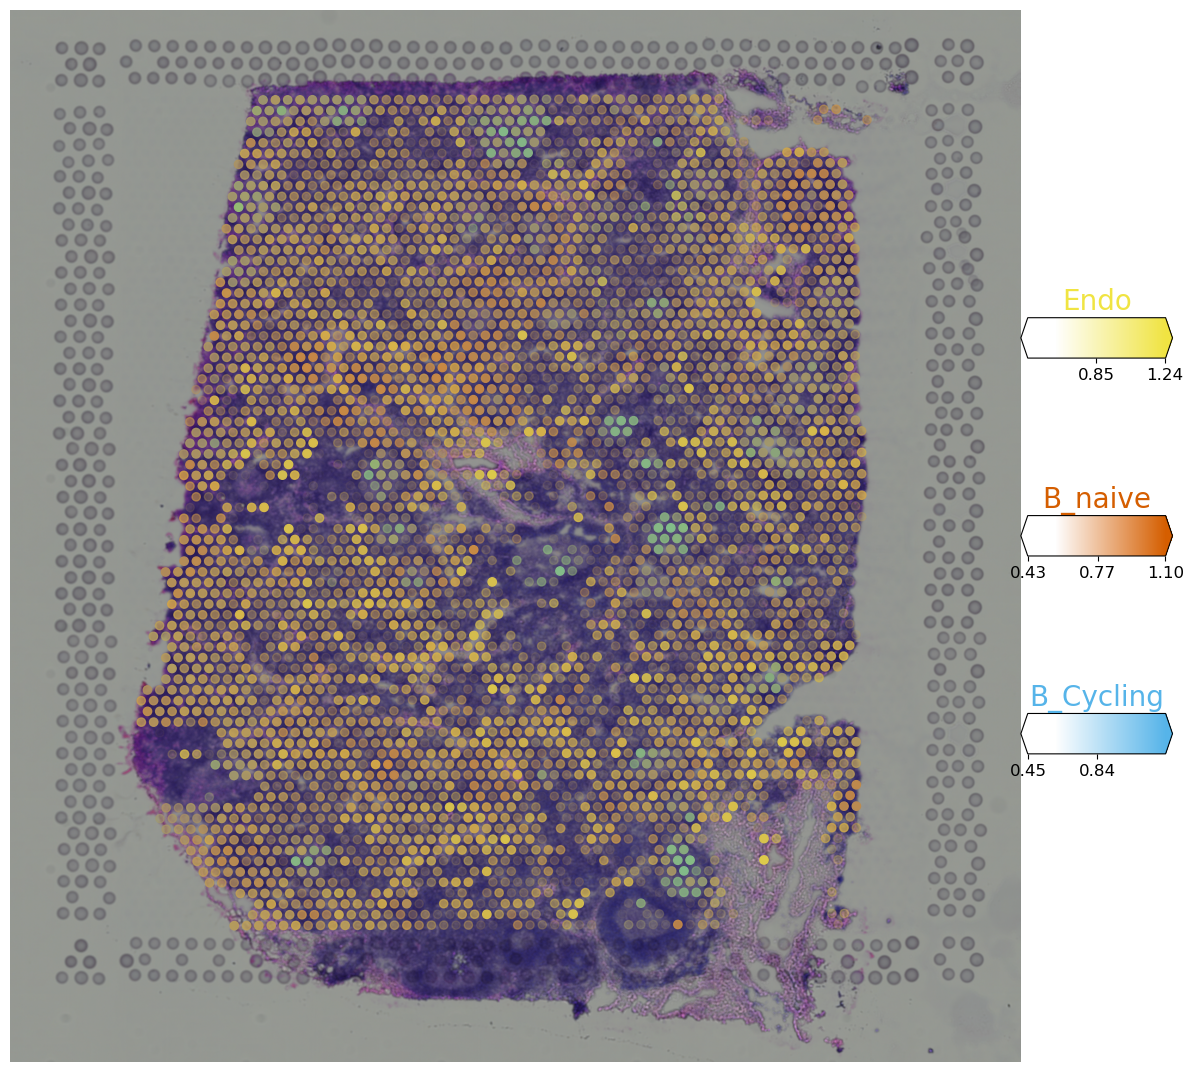

In [38]:
from cell2location.plt import plot_spatial

clust_labels = ['Endo', 'B_naive', 'B_Cycling']
clust_col = ['' + str(i) for i in clust_labels]

with mpl.rc_context({'figure.figsize': (15, 15)}):
    fig = plot_spatial(
        adata=slide,
        color=clust_col,
        labels=clust_labels,
        show_img=True,
        style='fast',
        max_color_quantile=0.992,
        circle_diameter=6,
        colorbar_position='right',
    )

## 8. 下游分析 1：Leiden 区域识别

**目的**：依据“细胞组成相似性”而非原始表达进行组织区域划分。  
**原理**：
1. 用 cell2location 丰度构建 KNN 图
2. Leiden 聚类得到区域标签
3. UMAP 展示区域间关系

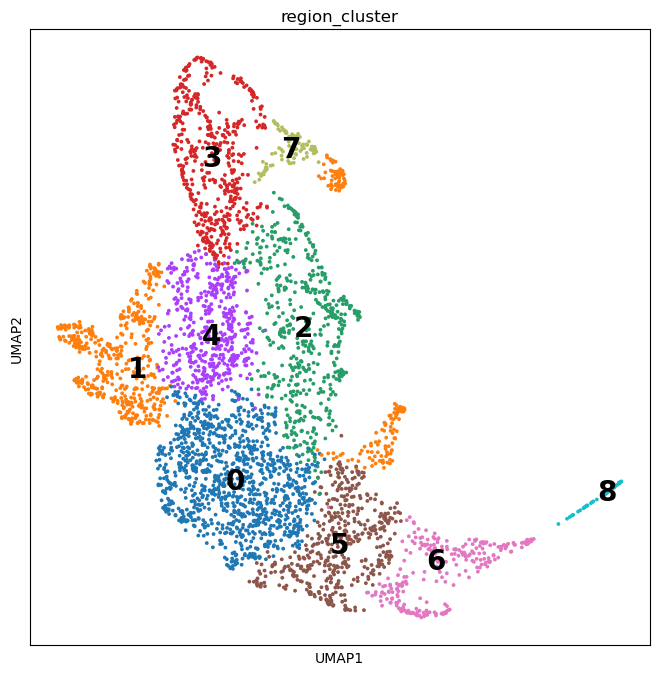

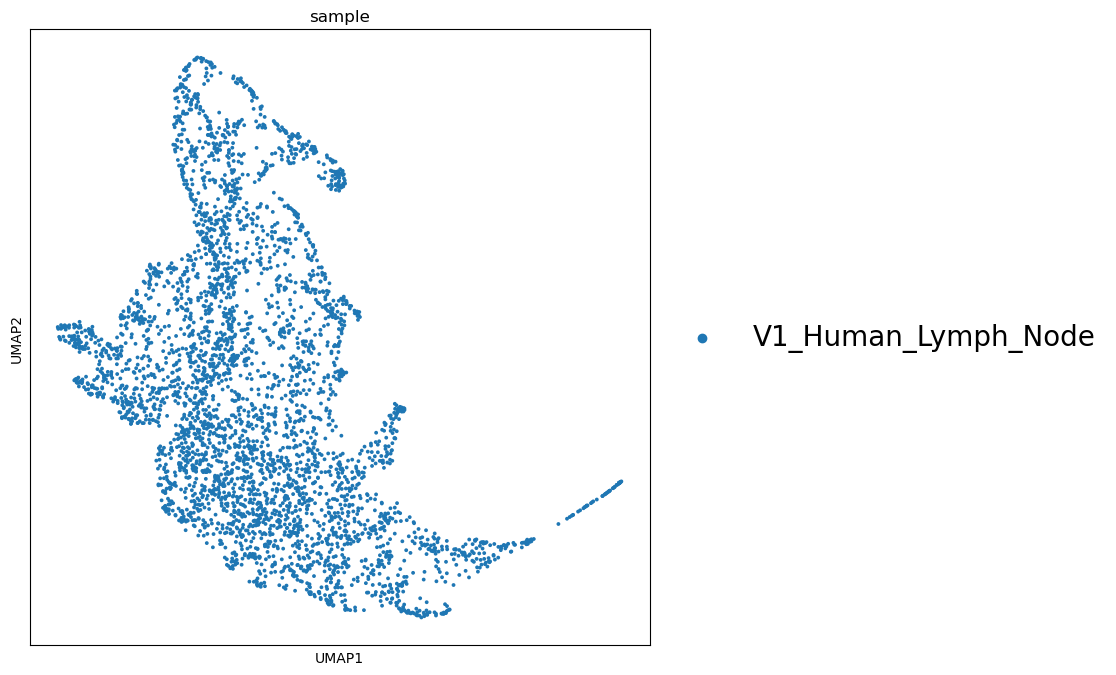

/tmp/ipykernel_842/1800005207.py:12: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_vis, color=['region_cluster'], size=1.3, img_key='hires', alpha=0.5)


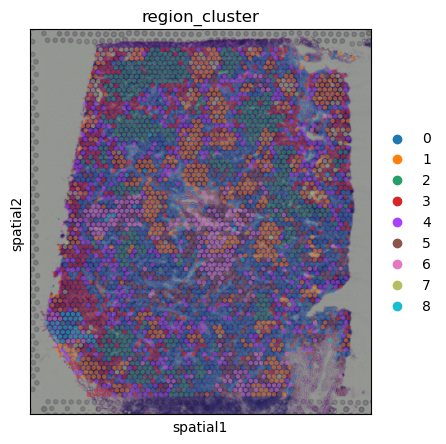

In [39]:
sc.pp.neighbors(adata_vis, use_rep='q05_cell_abundance_w_sf', n_neighbors=15)
sc.tl.leiden(adata_vis, resolution=0.3)
adata_vis.obs['region_cluster'] = adata_vis.obs['leiden'].astype('category')

sc.tl.umap(adata_vis, min_dist=0.3, spread=1)

with mpl.rc_context({'axes.facecolor': 'white', 'figure.figsize': [8, 8]}):
    sc.pl.umap(adata_vis, color=['region_cluster'], size=30, color_map='RdPu', legend_loc='on data', legend_fontsize=20)
    sc.pl.umap(adata_vis, color=['sample'], size=30, color_map='RdPu', legend_fontsize=20)

with mpl.rc_context({'axes.facecolor': 'black', 'figure.figsize': [4.5, 5]}):
    sc.pl.spatial(adata_vis, color=['region_cluster'], size=1.3, img_key='hires', alpha=0.5)

## 9. 版本记录（复现与排错）

**目的**：保存软件版本信息，便于复现实验结果和定位兼容性问题。

In [45]:
cell2location.utils.list_imported_modules()
cell2location.__version__

sys 3.10.17 | packaged by conda-forge | (main, Apr 10 2025, 22:19:12) [GCC 13.3.0]
re 2.2.1
ipaddress 1.0
ipykernel._version 6.31.0
json 2.0.9
jupyter_client._version 8.6.3
platform 1.0.8
zlib 1.0
zmq.sugar.version 27.1.0
zmq.sugar 27.1.0
zmq 27.1.0
logging 0.5.1.2
traitlets._version 5.14.3
traitlets 5.14.3
jupyter_core.version 5.7.2
jupyter_core 5.7.2
tornado 6.5
_ctypes 1.1.0
ctypes 1.1.0
colorama 0.4.6
_curses b'2.2'
socketserver 0.4
argparse 1.1
dateutil._version 2.9.0.post0
dateutil 2.9.0.post0
six 1.17.0
_decimal 1.70
decimal 1.70
platformdirs.version 4.3.8
platformdirs 4.3.8
_csv 1.0
csv 1.0
jupyter_client 8.6.3
ipykernel 6.31.0
IPython.core.release 8.36.0
executing.version 2.2.0
executing 2.2.0
pure_eval.version 0.2.3
pure_eval 0.2.3
stack_data.version 0.6.3
stack_data 0.6.3
pygments 2.19.1
IPython.core.crashhandler 8.36.0
pickleshare 0.7.5
decorator 5.2.1
_sqlite3 2.6.0
sqlite3.dbapi2 2.6.0
sqlite3 2.6.0
exceptiongroup._version 1.3.0
exceptiongroup 1.3.0
wcwidth 0.2.13
prompt_

'0.1.4'